# **MORTALITY - merged csv**




### A little EDA

In [ ]:
# imports and libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SkPipe
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support

In [ ]:
# load in data
mortality_merged = pd.read_csv("mortality_base.csv")
mortality_merged.head(10)

,patientunitstayid,age,gender,ethnicity,unittype,acutephysiologyscore,apachescore,apacheversion,predictedicumortality,actualicumortality,...,hr_mean,rr_mean,sao2_mean,temp_mean,map_mean,glucose_mean,creatinine_mean,bun_mean,sodium_mean,potassium_mean
0,141765,87,Female,Caucasian,Med-Surg ICU,23,47,IVa,0.012311,ALIVE,...,83.190972,5.937500,69.437500,0.000000,0.000000,75.000000,1.040,28.0,139.0,4.1
1,143870,76,Male,Caucasian,SICU,43,60,IVa,0.015707,ALIVE,...,45.449367,67.031646,96.284810,0.000000,60.835443,131.500000,1.015,13.5,136.0,4.4
2,144815,34,Female,Caucasian,Med-Surg ICU,25,25,IVa,0.002133,ALIVE,...,83.800000,16.927273,78.904545,0.000000,0.000000,82.000000,0.630,6.0,141.0,3.7
3,145427,61,Male,Caucasian,SICU,26,37,IVa,0.007556,ALIVE,...,65.457983,8.655462,50.697479,0.000000,0.000000,128.500000,1.050,14.0,141.0,4.5
4,147307,55,Female,Caucasian,Med-Surg ICU,15,20,IVa,0.001932,ALIVE,...,87.085106,8.308511,55.404255,0.000000,81.053191,NaN,NaN,NaN,NaN,NaN
5,147784,60,Female,Hispanic,Med-Surg ICU,53,64,IVa,0.047941,ALIVE,...,93.720280,24.590909,94.520979,0.000000,0.000000,137.833333,0.640,17.0,143.0,4.3
6,148611,28,Male,Caucasian,Med-Surg ICU,16,16,IVa,0.001274,ALIVE,...,79.442231,22.011952,95.864542,0.000000,0.000000,112.000000,0.820,7.0,142.0,3.7
7,149713,> 89,Female,Caucasian,Med-Surg ICU,33,57,IVa,0.032460,ALIVE,...,72.448718,31.337607,48.141026,0.000000,0.000000,97.000000,0.610,11.0,133.0,3.9
8,151179,59,Female,Caucasian,Med-Surg ICU,125,141,IVa,0.557378,ALIVE,...,98.286713,26.846154,96.024476,7.378497,0.000000,87.000000,2.205,62.0,143.5,4.5
9,151867,44,Male,Caucasian,SICU,14,14,IVa,0.002713,ALIVE,...,94.742537,13.097015,62.044776,0.000000,0.000000,119.500000,1.070,10.0,136.0,3.9


In [ ]:
mortality_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patientunitstayid           1838 non-null   int64  
 1   age                         1835 non-null   object 
 2   gender                      1837 non-null   object 
 3   ethnicity                   1817 non-null   object 
 4   unittype                    1838 non-null   object 
 5   acutephysiologyscore        1838 non-null   int64  
 6   apachescore                 1838 non-null   int64  
 7   apacheversion               1838 non-null   object 
 8   predictedicumortality       1838 non-null   float64
 9   actualicumortality          1838 non-null   object 
 10  predictedhospitalmortality  1838 non-null   float64
 11  actualhospitalmortality     1838 non-null   object 
 12  hr_mean                     1806 non-null   float64
 13  rr_mean                     1806 

In [ ]:
# looking at basic stats
mortality_merged.describe(include='all')

,patientunitstayid,age,gender,ethnicity,unittype,acutephysiologyscore,apachescore,apacheversion,predictedicumortality,actualicumortality,...,hr_mean,rr_mean,sao2_mean,temp_mean,map_mean,glucose_mean,creatinine_mean,bun_mean,sodium_mean,potassium_mean
count,1.838000e+03,1835,1837,1817,1838,1838.000000,1838.000000,1838,1838.000000,1838,...,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1680.000000,1619.000000,1613.000000,1620.000000,1595.000000
unique,NaN,75,2,6,8,NaN,NaN,1,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,> 89,Male,Caucasian,Med-Surg ICU,NaN,NaN,IVa,NaN,ALIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,74,1127,1434,1375,NaN,NaN,1838,NaN,1747,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.768430e+06,NaN,NaN,NaN,NaN,40.354733,51.956474,NaN,0.013221,NaN,...,83.981905,17.202481,86.136144,2.160980,10.774708,142.543765,2.746264,25.108473,136.825904,4.083706
std,1.015549e+06,NaN,NaN,NaN,NaN,22.703872,25.253063,NaN,0.251673,NaN,...,17.030820,7.227699,20.732994,8.736345,25.344985,57.113372,9.858406,18.874201,10.171181,0.620105
min,1.417650e+05,NaN,NaN,NaN,NaN,-1.000000,-1.000000,NaN,-1.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,0.000000,2.000000,36.000000,2.300000
25%,9.643230e+05,NaN,NaN,NaN,NaN,26.000000,35.250000,NaN,0.007030,NaN,...,72.112757,14.945909,86.369343,0.000000,0.000000,105.000000,0.760000,13.000000,135.000000,3.700000
50%,1.711216e+06,NaN,NaN,NaN,NaN,36.000000,48.000000,NaN,0.019704,NaN,...,82.492614,17.863955,94.640433,0.000000,0.000000,128.000000,1.000000,19.000000,138.437500,4.000000
75%,2.754142e+06,NaN,NaN,NaN,NaN,51.000000,65.000000,NaN,0.054020,NaN,...,95.919021,21.093629,96.934165,0.000000,0.000000,163.000000,1.562500,31.000000,141.000000,4.400000


In [ ]:
# looking at missing values
mortality_merged.isna().sum().sort_values(ascending=False)

potassium_mean                243
bun_mean                      225
creatinine_mean               219
sodium_mean                   218
glucose_mean                  158
rr_mean                        32
map_mean                       32
temp_mean                      32
sao2_mean                      32
hr_mean                        32
ethnicity                      21
age                             3
gender                          1
patientunitstayid               0
predictedhospitalmortality      0
actualicumortality              0
predictedicumortality           0
apacheversion                   0
apachescore                     0
acutephysiologyscore            0
unittype                        0
actualhospitalmortality         0
dtype: int64

In [ ]:
list(mortality_merged)

['patientunitstayid',
 'age',
 'gender',
 'ethnicity',
 'unittype',
 'acutephysiologyscore',
 'apachescore',
 'apacheversion',
 'predictedicumortality',
 'actualicumortality',
 'predictedhospitalmortality',
 'actualhospitalmortality',
 'hr_mean',
 'rr_mean',
 'sao2_mean',
 'temp_mean',
 'map_mean',
 'glucose_mean',
 'creatinine_mean',
 'bun_mean',
 'sodium_mean',
 'potassium_mean']

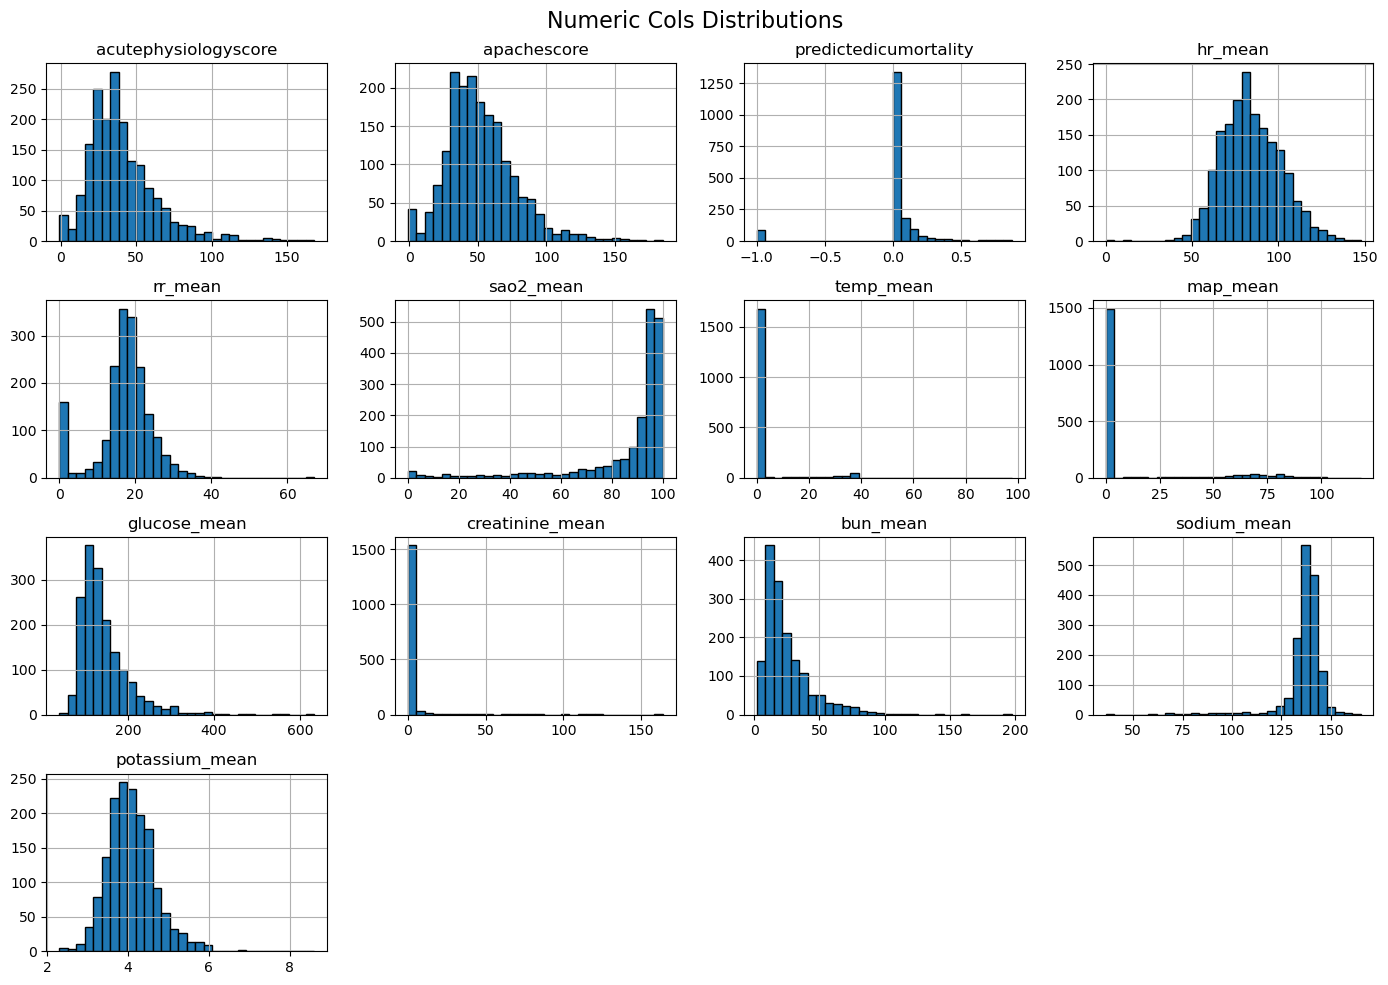

In [ ]:
# looking the at the distributions for numerical columns
num_cols = [
    'acutephysiologyscore','apachescore','predictedicumortality',
    'hr_mean','rr_mean','sao2_mean','temp_mean','map_mean',
    'glucose_mean','creatinine_mean','bun_mean','sodium_mean','potassium_mean'
]

mortality_merged[num_cols].hist(figsize=(14,10), bins=30, edgecolor='black')
plt.suptitle('Numeric Cols Distributions', fontsize=16)
plt.tight_layout()
plt.show()

Notes:
- APACHE & acute physiology scores: kinda bell shaped but w/ outliers, probably need to replace −1 to nan
- predicted ICU mortality: right skewed near 0 (most are predicted low risk)
- vitals (hr_mean, rr_mean): okay ranges, roughly normal, zeros can be treated as missing
- SaO2, temp, MAP have clear spikes at zero so likely missing/improperly recorded
- labs (Glucose, Creatinine, BUN) strongly right-skewed, some extreme outliers (log transformation)
- electrolytes (Sodium, Potassium) range are ok,there's a few that are low

Next:
- replace negatives/zeros w/ nan
- log transform for right skewed labs (glucose_mean, bun_mean, creatinine_mean)

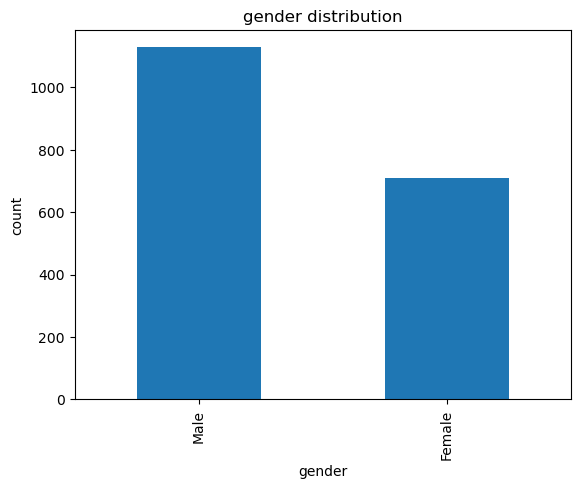

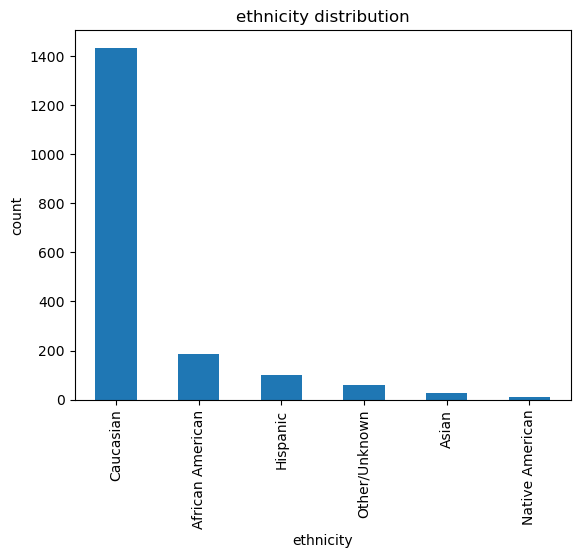

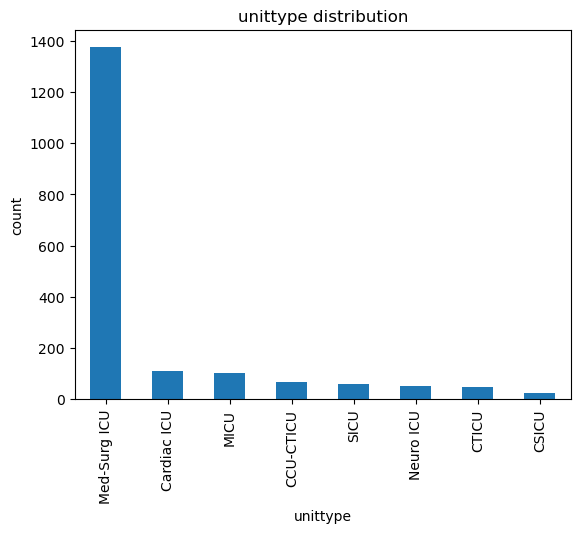

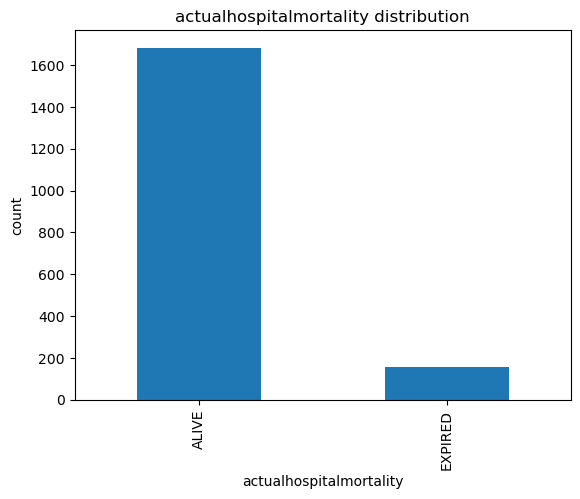

In [ ]:
# catergorical distributions
cat_cols = ['gender','ethnicity','unittype','actualhospitalmortality']

for col in cat_cols:
    mortality_merged[col].value_counts().plot(kind='bar')
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

notes:
- gender: slightly more males in the ICU than females, so a mild imbalance
- ethnicity: dominated by Caucasian, small minority representation (will create bias in model)
- ICU type: Med-Surg ICU takes majority, heavy imbalance.
- mortality outcome: high high imbalance, most patients ALIVE, few EXPIRED


what we can do next:
- handle class imbalance (e.g., SMOTE, class weighting, or stratified split)
- combine or do grouping to other ethnicities and ICU types

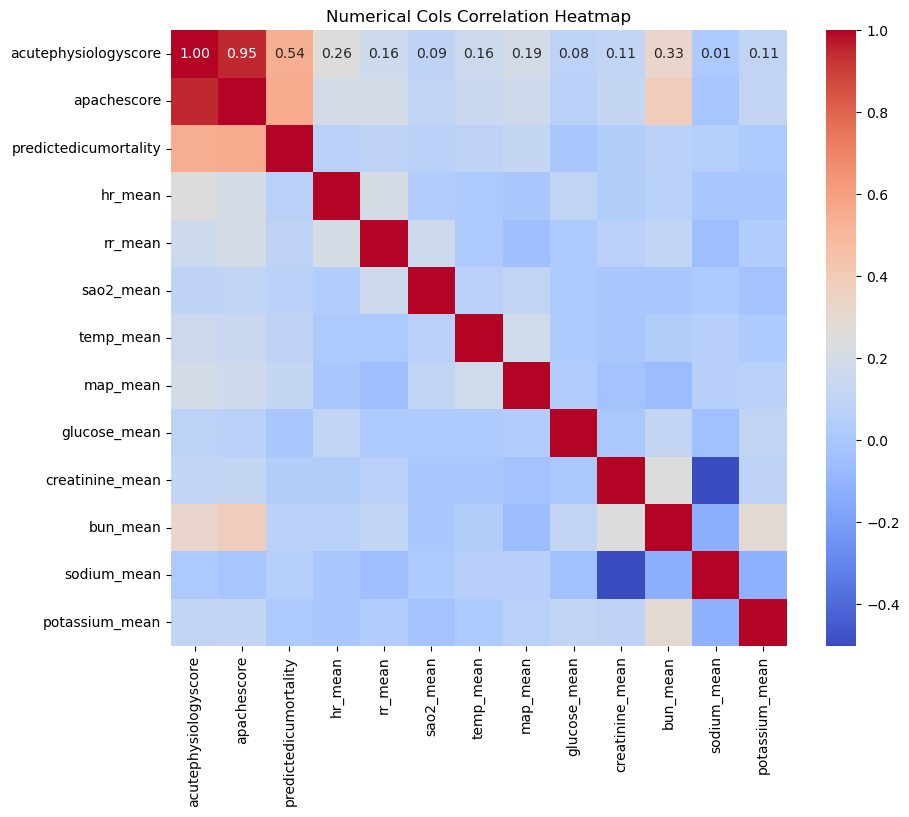

In [ ]:
# numerical cols correlation heatmap
num_corr = mortality_merged[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Numerical Cols Correlation Heatmap")
plt.show()

notes:
- strong between acutephysiologyscore and apachescore but that can be redundant so might consider dropping one
- slight positive correlation between BUN and Creatinine (renal function)
- BUT most vitals/labs have low inter-corr (< 0.3), so likely complementary predictors


what to do:
- probably keep one of APACHE/APS to prevent multicollinearity
- check variance inflation factor (VIF) later

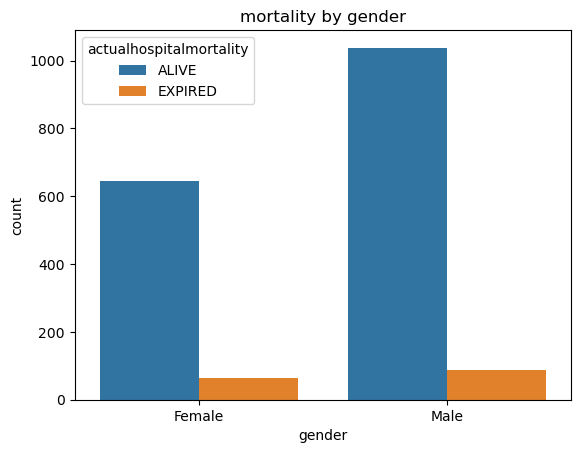

In [ ]:
# lookiing into target relationships and how mortality differs across groups or continuous values...

# categorical vs mortality
sns.countplot(x='gender', hue='actualhospitalmortality', data=mortality_merged)
plt.title("mortality by gender")
plt.show()

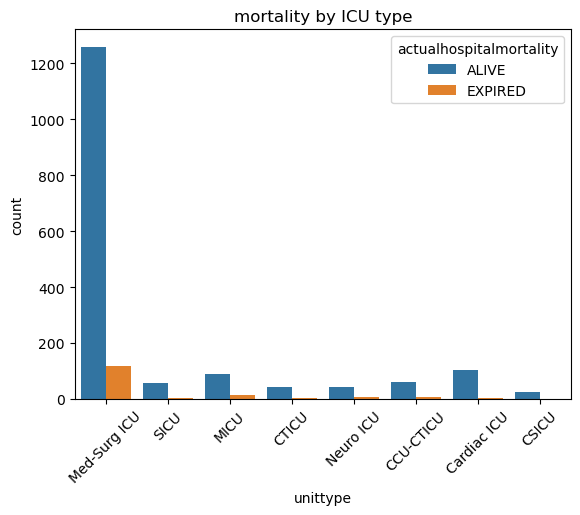

In [ ]:
sns.countplot(x='unittype', hue='actualhospitalmortality', data=mortality_merged)
plt.xticks(rotation=45)
plt.title("mortality by ICU type")
plt.show()

notes:
- ICU Type: slightly higher death rate in cardiac or neuro ICU, but small sample sizes

next: maybe quantify differences with chi-square

In [ ]:
# numerical vs mortality

# create num mortality col (0 = ALIVE, 1 = EXPIRED)
mortality_merged['mortality_num'] = mortality_merged['actualhospitalmortality'].map({'ALIVE': 0, 'EXPIRED': 1})
print(mortality_merged['mortality_num'].value_counts(dropna=False))

mortality_num
0    1683
1     155
Name: count, dtype: int64


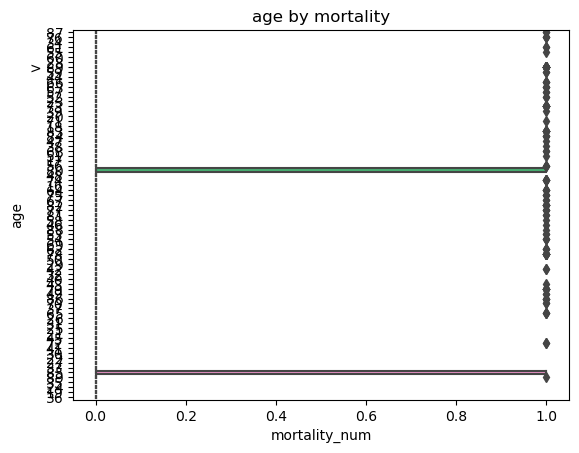

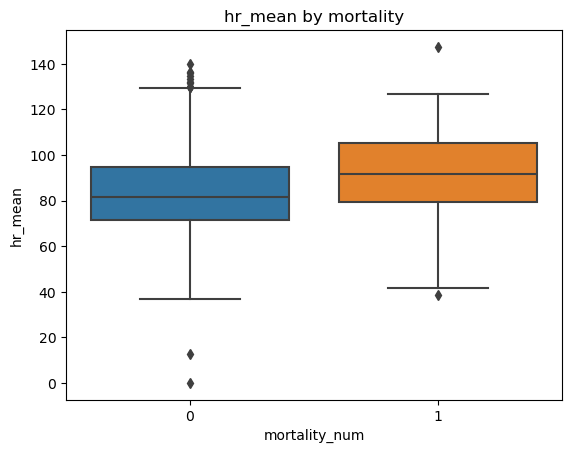

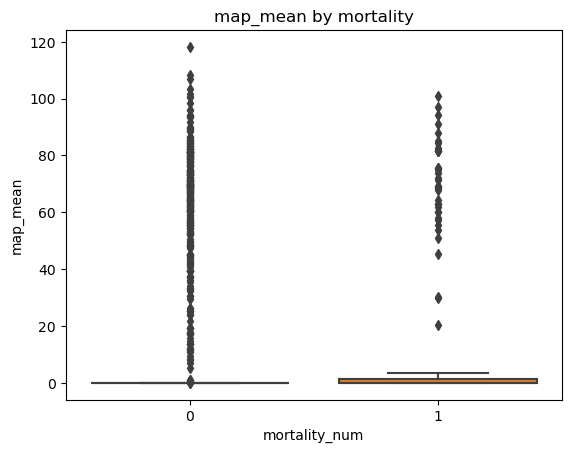

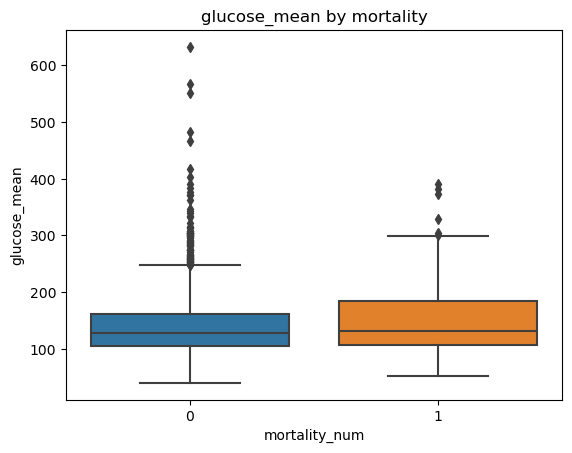

In [ ]:
for col in ['age','hr_mean','map_mean','glucose_mean']:
    sns.boxplot(x='mortality_num', y=col, data=mortality_merged)
    plt.title(f"{col} by mortality")
    plt.show()

boxplot notes:

age:
- the “>89” category caused that stacked banding on the y axis, meaning the col is still stored as strings
- most expired patients are in the older group,when age is numeric, lets see if theres a higher median for mortality = 1.

hr_mean:
- slight upward shift for expired patients,higher HR associated w/ worse outcome
- outliers around zero should be treated as missing, otherwise they distort spread

map_mean:
- both groups have huge zero spikes and compressed boxes, indicates MAP = 0 as placeholder
- once invalid zeros are removed, likely lower MAP correlates w/ mortality

glucose_mean:
- deceased patients show a slightly higher and wider range, but strong right skew
- outliers > 400 mg/dL could dominate the mean


next:
- convert age to numeric
- replace zeros < 30 bpm with nan, **if able, impute** median by ICU type or overall
- set MAP < 10 mmHg to NaN (impossible in living patients) and impute
- log transform glucose to reduce skew

/Users/darleneeligado/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/darleneeligado/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/darleneeligado/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/darleneeligado/anaconda3/lib/python3.11/site-pa

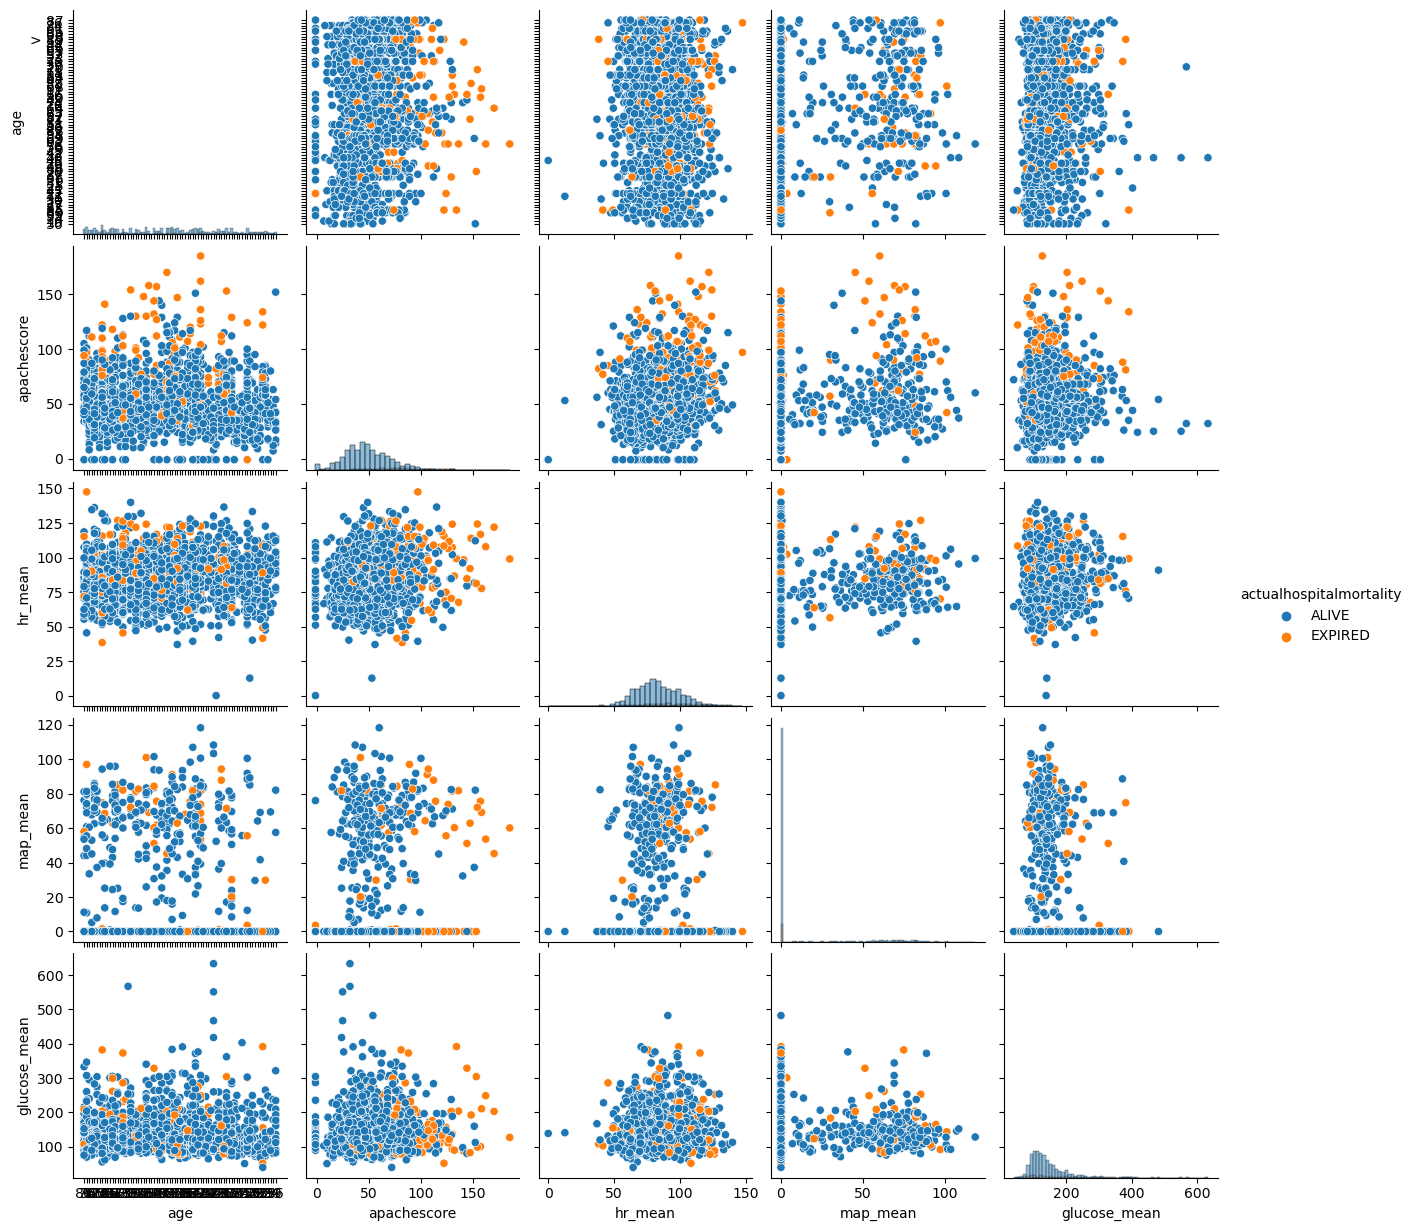

In [ ]:
sns.pairplot(mortality_merged, vars=['age','apachescore','hr_mean','map_mean','glucose_mean'],
             hue='actualhospitalmortality', diag_kind='hist')
plt.show()

pairplot notes:
- APACHE vs other vitals: higher APACHE roughly aligns w/ higher mortality points (in orange)
- age, HR, and MAP: weak trends, mortality points scatter across full range, the multivariate patterns may matter more than single variables
- no clear linear separations: suggests nonlinear models (Random Forest, XGBoost) may capture relationships better

----------
## **Data Cleaning**

fixing age and target

In [ ]:
mortality_cleaning = mortality_merged.copy()

# since age often has strings like "> 89" in eICU... convert to numeric
# mapping any ">89" to 90
mortality_cleaning['age'] = (
    mortality_cleaning['age']
    .astype(str)
    .str.replace('> 89', '90', regex=False)
    .str.replace('>89', '90', regex=False)
    .str.extract(r'(\d+)', expand=False)
    .astype(float)
)

In [ ]:
# binary target for and keeping original too
mortality_cleaning['mortality_num'] = (mortality_cleaning['actualhospitalmortality'] == 'EXPIRED').astype(int)

# making key categoricals explicit categories (helps with plotting & memory)
for c in ['gender','ethnicity','unittype','apacheversion','actualhospitalmortality']:
    mortality_cleaning[c] = mortality_cleaning[c].astype('category')

handling invalid values

In [ ]:
# eICU stores -1 for "unknown" in some APACHE fields, set to nan (missing)
neg_to_nan = ['acutephysiologyscore', 'apachescore',
              'predictedicumortality', 'predictedhospitalmortality']
for c in neg_to_nan:
    mortality_cleaning.loc[mortality_cleaning[c].lt(0), c] = np.nan

In [ ]:
# exact 0s in some vitals are physiologically unrealistic in recorded means
# these will be treated as missing
zero_impossible = ['hr_mean','rr_mean','sao2_mean','temp_mean','map_mean']
for c in zero_impossible:
    mortality_cleaning.loc[mortality_cleaning[c] == 0, c] = np.nan

# < 10 mmHg blood pressure this low can’t support life
mortality_cleaning['map_mean']  = pd.to_numeric(mortality_cleaning['map_mean'],  errors='coerce')
mortality_cleaning.loc[mortality_cleaning['map_mean']  < 10, 'map_mean']  = np.nan

# oxygen Saturation < 50%, oxygen that low is extremely rare and likely an error
mortality_cleaning['sao2_mean'] = pd.to_numeric(mortality_cleaning['sao2_mean'], errors='coerce')
mortality_cleaning.loc[mortality_cleaning['sao2_mean'] < 50, 'sao2_mean'] = np.nan

In [ ]:
# adding a marker that shows “this is missing”
# can be a valuable for predicting patient outcomes in ICU data to numerical vars
num_cols = [
    'acutephysiologyscore','apachescore','predictedicumortality','predictedhospitalmortality',
    'hr_mean','rr_mean','sao2_mean','temp_mean','map_mean',
    'glucose_mean','creatinine_mean','bun_mean','sodium_mean','potassium_mean'
]
for c in num_cols:
    mortality_cleaning[f'{c}_was_missing'] = mortality_cleaning[c].isna().astype(int)

In [ ]:
# median impution
group_cols = ['unittype']

# missing vitals and labs imputing using the median value within ea. ICU type
for c in num_cols:
    grp_med = mortality_cleaning.groupby(group_cols)[c].transform('median')
    mortality_cleaning[c] = mortality_cleaning[c].fillna(grp_med)
    mortality_cleaning[c] = mortality_cleaning[c].fillna(mortality_cleaning[c].median())

/var/folders/x4/884p4sk97gs4f8n6js6qwc1h0000gn/T/ipykernel_8141/4159994768.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp_med = mortality_cleaning.groupby(group_cols)[c].transform('median')


In [ ]:
# handling the outliers

#WINSORIZATION
# to reduce the influence of outliers by replacing extreme values w/ less extreme ones from a specified percentile (0.5th–99.5th pct)
# just mainly handling the extreme outliers with this one so its minimal?
skewed_labs = ['glucose_mean','creatinine_mean','bun_mean']
for c in skewed_labs:
    lo, hi = mortality_cleaning[c].quantile([0.005, 0.995])
    mortality_cleaning[c] = mortality_cleaning[c].clip(lower=lo, upper=hi)

# a copy of log transformation just in case, this one will be more normalized
for c in skewed_labs:
    mortality_cleaning[f'log_{c}'] = np.log1p(mortality_cleaning[c])

In [ ]:
#### CLEANIING SUMMARY TABLE
# table of missing counts before/after and % imputed for listed cols :/
def summary_cleaning(original: pd.DataFrame, cleaned: pd.DataFrame, cols: list) -> pd.DataFrame:
    out = []
    for c in cols:
        before_na = original[c].isna().sum()
        after_na  = cleaned[c].isna().sum()
        # count how many values were imputed
        imputed = cleaned[f'{c}_was_missing'].sum()
        out.append({
            'column': c,
            'missing_before': int(before_na),
            'missing_after':  int(after_na),
            'imputed_count':  int(imputed),
            'imputed_pct':    round(100 * imputed / len(cleaned), 2)
        })
    return pd.DataFrame(out).sort_values('imputed_pct', ascending=False)

cleaning_table = summary_cleaning(mortality_merged, mortality_cleaning, num_cols)
cleaning_table

,column,missing_before,missing_after,imputed_count,imputed_pct
7,temp_mean,32,0,1709,92.98
8,map_mean,32,0,1532,83.35
13,potassium_mean,243,0,243,13.22
11,bun_mean,225,0,225,12.24
10,creatinine_mean,219,0,219,11.92
12,sodium_mean,218,0,218,11.86
6,sao2_mean,32,0,176,9.58
5,rr_mean,32,0,169,9.19
9,glucose_mean,158,0,158,8.60
3,predictedhospitalmortality,0,0,155,8.43


In [ ]:
# looking at original 0s
(mortality_merged['temp_mean'] == 0).sum(), (mortality_merged['map_mean'] == 0).sum()

(np.int64(1677), np.int64(1484))

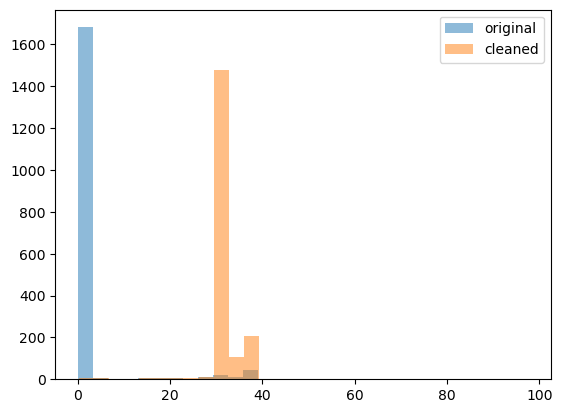

In [ ]:
# compare original and cleaned temp_mean
plt.hist(mortality_merged['temp_mean'], bins=30, alpha=0.5, label='original')
plt.hist(mortality_cleaning['temp_mean'], bins=30, alpha=0.5, label='cleaned')
plt.legend()
plt.show()

Few things to note:
- roughly 90% of the temperature originaldata consisted of these zero placeholders.we replaced missing values with the median temperature within each ICU type ( now ~36–37°C), restoring a realistic distribution consistent with  anormal human body temperature.
- values of 0 mmHg were treated as missing due to averages are physiologically impossible so around 83% of MAP records were affected. Missing MAP values were imputed using median MAP values within each ICU type

-------

## **Checking Cleaning Done**


In [ ]:
mortality_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 40 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   patientunitstayid                       1838 non-null   int64   
 1   age                                     1835 non-null   float64 
 2   gender                                  1837 non-null   category
 3   ethnicity                               1817 non-null   category
 4   unittype                                1838 non-null   category
 5   acutephysiologyscore                    1838 non-null   float64 
 6   apachescore                             1838 non-null   float64 
 7   apacheversion                           1838 non-null   category
 8   predictedicumortality                   1838 non-null   float64 
 9   actualicumortality                      1838 non-null   object  
 10  predictedhospitalmortality              1838 non

In [ ]:
mortality_cleaning.describe(include='all')

,patientunitstayid,age,gender,ethnicity,unittype,acutephysiologyscore,apachescore,apacheversion,predictedicumortality,actualicumortality,...,temp_mean_was_missing,map_mean_was_missing,glucose_mean_was_missing,creatinine_mean_was_missing,bun_mean_was_missing,sodium_mean_was_missing,potassium_mean_was_missing,log_glucose_mean,log_creatinine_mean,log_bun_mean
count,1.838000e+03,1835.000000,1837,1817,1838,1838.000000,1838.000000,1838,1.838000e+03,1838,...,1838.000000,1838.000000,1838.000000,1838.000000,1838.000000,1838.000000,1838.000000,1838.000000,1838.000000,1838.000000
unique,NaN,NaN,2,6,8,NaN,NaN,1,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Male,Caucasian,Med-Surg ICU,NaN,NaN,IVa,NaN,ALIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,1434,1375,NaN,NaN,1838,NaN,1747,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.768430e+06,63.007629,NaN,NaN,NaN,41.183896,53.074538,NaN,6.046349e-02,NaN,...,0.929815,0.833515,0.085963,0.119151,0.122416,0.118607,0.132209,4.900405,0.851076,3.054497
std,1.015549e+06,17.805350,NaN,NaN,NaN,21.840889,23.960033,NaN,1.166498e-01,NaN,...,0.255528,0.372617,0.280386,0.324055,0.327854,0.323414,0.338810,0.316443,0.566126,0.577166
min,1.417650e+05,16.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,3.471517e-09,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.235446,0.263786,1.609438
25%,9.643230e+05,52.000000,NaN,NaN,NaN,26.000000,36.000000,NaN,9.024477e-03,NaN,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.687825,0.587787,2.708050
50%,1.711216e+06,66.000000,NaN,NaN,NaN,36.000000,49.000000,NaN,2.149710e-02,NaN,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.853485,0.693147,3.020425
75%,2.754142e+06,77.000000,NaN,NaN,NaN,51.000000,65.000000,NaN,5.401969e-02,NaN,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.071887,0.875469,3.401197


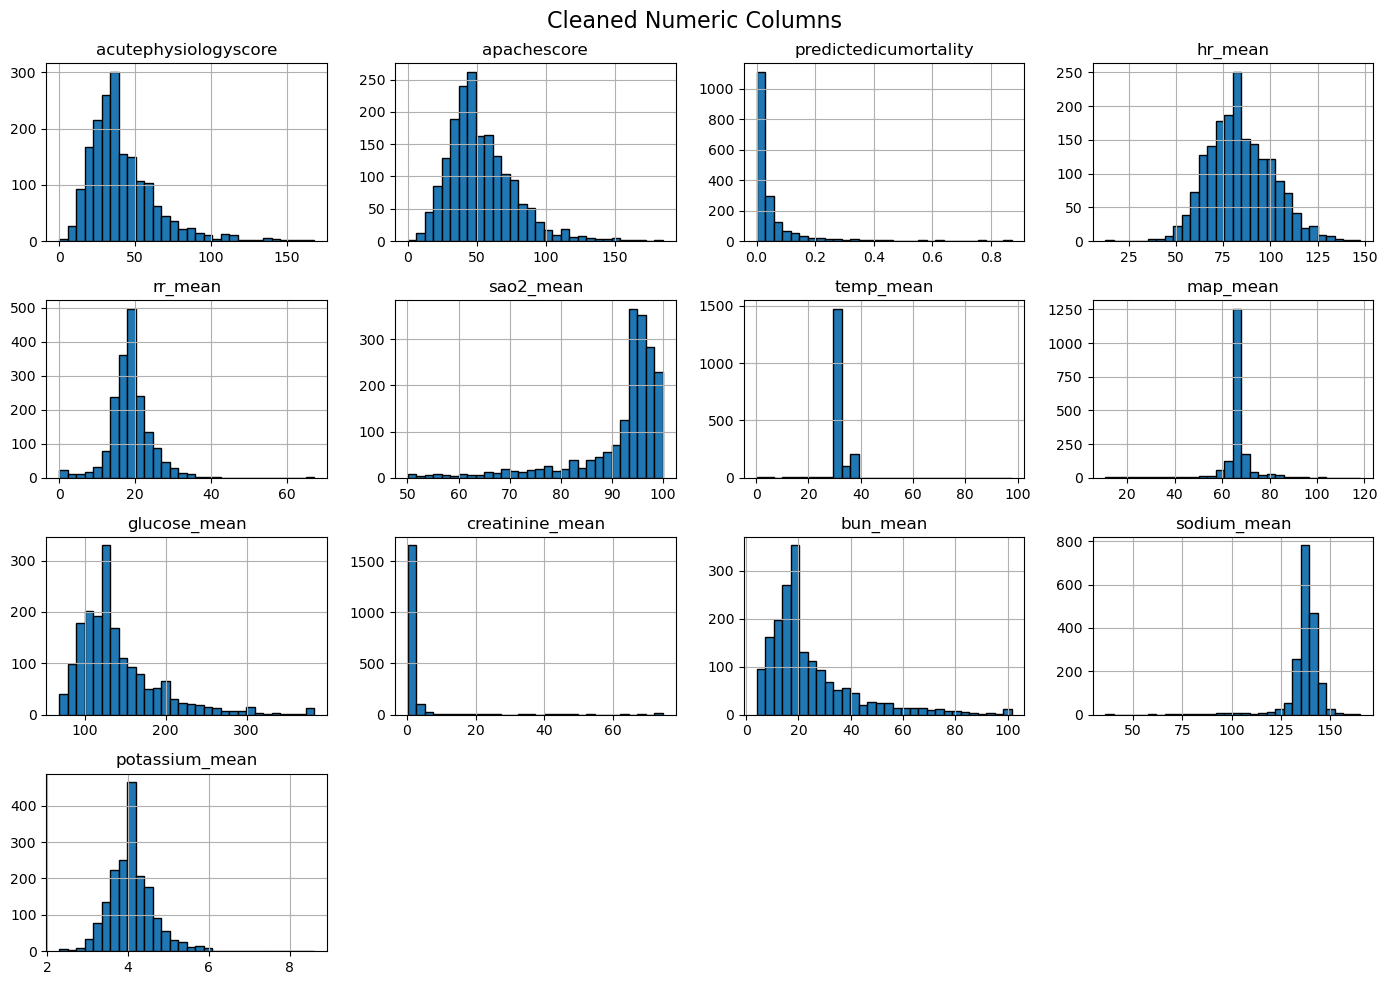

In [ ]:
num_cols = [
    'acutephysiologyscore','apachescore','predictedicumortality',
    'hr_mean','rr_mean','sao2_mean','temp_mean','map_mean',
    'glucose_mean','creatinine_mean','bun_mean','sodium_mean','potassium_mean'
]

mortality_cleaning[num_cols].hist(figsize=(14,10), bins=30, edgecolor='black')
plt.suptitle('Cleaned Numeric Columns', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
mortality_cleaning.isna().sum().sort_values(ascending=False).head(40)

ethnicity                                 21
age                                        3
gender                                     1
temp_mean_was_missing                      0
acutephysiologyscore_was_missing           0
apachescore_was_missing                    0
predictedicumortality_was_missing          0
predictedhospitalmortality_was_missing     0
hr_mean_was_missing                        0
rr_mean_was_missing                        0
sao2_mean_was_missing                      0
patientunitstayid                          0
map_mean_was_missing                       0
mortality_num                              0
creatinine_mean_was_missing                0
bun_mean_was_missing                       0
sodium_mean_was_missing                    0
potassium_mean_was_missing                 0
log_glucose_mean                           0
log_creatinine_mean                        0
glucose_mean_was_missing                   0
sodium_mean                                0
potassium_

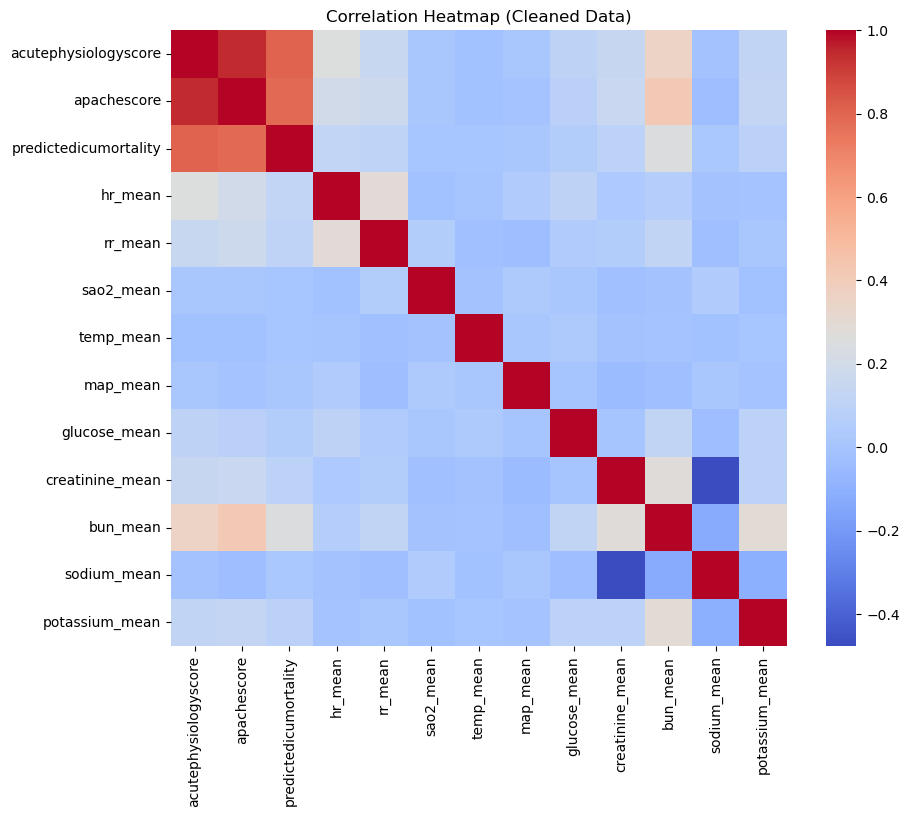

In [ ]:
clean_corr = mortality_cleaning[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(clean_corr, annot=False, cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Cleaned Data)")
plt.show()

- few strong relationships (like between APACHE and AcutePhysiologyScore)
- still most vitals/labs show weak to moderate correlations w/ each other and w/ mortality predictors
- no obvious linear trend patterns

In [ ]:
# will just handle the few missing values for gender, age, and ethnicity

# gender filled it w/ the mode
mortality_cleaning['gender'] = mortality_cleaning['gender'].fillna(mortality_cleaning['gender'].mode()[0])

# age filled in with the median
mortality_cleaning['age'] = mortality_cleaning['age'].fillna(mortality_cleaning['age'].median())

# missing trrated as: “Unknown”
mortality_cleaning['ethnicity'] = mortality_cleaning['ethnicity'].cat.add_categories('Unknown')
mortality_cleaning['ethnicity'] = mortality_cleaning['ethnicity'].fillna('Unknown')

In [ ]:
mortality_cleaning.isna().sum().sort_values(ascending=False).head(40)

patientunitstayid                         0
age                                       0
mortality_num                             0
acutephysiologyscore_was_missing          0
apachescore_was_missing                   0
predictedicumortality_was_missing         0
predictedhospitalmortality_was_missing    0
hr_mean_was_missing                       0
rr_mean_was_missing                       0
sao2_mean_was_missing                     0
temp_mean_was_missing                     0
map_mean_was_missing                      0
glucose_mean_was_missing                  0
creatinine_mean_was_missing               0
bun_mean_was_missing                      0
sodium_mean_was_missing                   0
potassium_mean_was_missing                0
log_glucose_mean                          0
log_creatinine_mean                       0
potassium_mean                            0
sodium_mean                               0
bun_mean                                  0
actualicumortality              

-------------

## **Preprocessing**

In [ ]:
# target and features
mortality_preproces = mortality_cleaning.copy()

y = mortality_preproces['mortality_num']
drop_cols = ['acutephysiologyscore']  # keeping 'apachescore'
feat_cols = [c for c in mortality_preproces.columns
             if c not in drop_cols
             and c not in ['patientunitstayid','actualhospitalmortality','mortality_num']]

X = mortality_preproces[feat_cols].copy()

In [ ]:
# 70/15/15 SPLIT
# first: train(70%) vs temp(30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

In [ ]:
# then: val(15%) vs test(15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

In [ ]:
# saving indices
split_idx = {
    "train": X_train.index.tolist(),
    "val":   X_val.index.tolist(),
    "test":  X_test.index.tolist()
}

In [ ]:
#one-hot & scale where needed
num_cols = [
    'apachescore','age','hr_mean','rr_mean','sao2_mean','temp_mean','map_mean',
    'glucose_mean','creatinine_mean','bun_mean','sodium_mean','potassium_mean',
    'log_glucose_mean','log_creatinine_mean','log_bun_mean'
] + [c for c in mortality_preproces.columns if c.endswith('_was_missing')]

cat_cols = ['gender','ethnicity','unittype','apacheversion']

In [ ]:
# pipeline for numeric cols
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # if still missing, fill w/ median
    ('scaler',  StandardScaler())
])


# pipeline for categorical cols
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # fill missing categories w/ mode
    ('ohe',     OneHotEncoder(handle_unknown='ignore'))
])

# combine
preprocess = ColumnTransformer([
    ('num', num_pipe, [c for c in num_cols if c in X.columns]),  # apply numeric pipeline to numeric cols
    ('cat', cat_pipe, [c for c in cat_cols if c in X.columns]),  # apply categorical pipeline to cat cols
], remainder='drop')

In [ ]:
# random forest model pipeline
rf_clf = SkPipe([
    ('prep', preprocess),
    ('model', RandomForestClassifier( # train model
        n_estimators=400,
        max_depth=None,
        min_samples_split=5,
        n_jobs=-1,
        class_weight='balanced', # handle class imbalance (deaths are rare)
        random_state=42
    ))
])

# train model
rf_clf.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# helper function to calculate metrics
def eval_with_threshold(model, X, y, thresh=0.5, label='set'):
    # get predicted probabilities (how confident the model is)
    proba = model.predict_proba(X)[:,1]  # the probability of class "1" (Expired)

    # turn probabilities into 0/1 predictions
    preds  = (proba >= thresh).astype(int)

    # metrics
    recall = precision_recall_fscore_support(y, preds, average='binary', zero_division=0)[1]
    prec   = precision_recall_fscore_support(y, preds, average='binary', zero_division=0)[0]
    f1     = precision_recall_fscore_support(y, preds, average='binary', zero_division=0)[2]
    auc    = roc_auc_score(y, proba)

    print(f"[{label}]  thresh={thresh:.2f}  Recall={recall:.3f}  Precision={prec:.3f}  F1={f1:.3f}  AUROC={auc:.3f}")

    # return metrics to compare later
    return {'recall':recall,'precision':prec,'f1':f1,'auroc':auc,'proba':proba}

In [ ]:
# evaluating default 0.5 threshold
_ = eval_with_threshold(rf_clf, X_val, y_val, 0.50, 'VAL@0.50')

# trying multiple thresholds to find best recall
proba_val = rf_clf.predict_proba(X_val)[:,1] # model’s predicted probabilities
thresholds = np.linspace(0.10, 0.90, 17) # test thresholds between 0.10 & 0.90
best = None

# loop thru thresholds and see which gives best recall
for t in thresholds:
    m = eval_with_threshold(rf_clf, X_val, y_val, t, f'VAL@{t:.2f}')
    if best is None or m['recall'] > best['recall']:
        best = {**m, 't': t}   # store the best threshold

best_t = best['t']
print(f"\nChosen threshold for best recall: {best_t:.2f}")

[VAL@0.50]  thresh=0.50  Recall=0.042  Precision=0.333  F1=0.074  AUROC=0.755
[VAL@0.10]  thresh=0.10  Recall=0.625  Precision=0.167  F1=0.263  AUROC=0.755
[VAL@0.15]  thresh=0.15  Recall=0.375  Precision=0.176  F1=0.240  AUROC=0.755
[VAL@0.20]  thresh=0.20  Recall=0.292  Precision=0.200  F1=0.237  AUROC=0.755
[VAL@0.25]  thresh=0.25  Recall=0.208  Precision=0.227  F1=0.217  AUROC=0.755
[VAL@0.30]  thresh=0.30  Recall=0.125  Precision=0.250  F1=0.167  AUROC=0.755
[VAL@0.35]  thresh=0.35  Recall=0.125  Precision=0.429  F1=0.194  AUROC=0.755
[VAL@0.40]  thresh=0.40  Recall=0.125  Precision=0.600  F1=0.207  AUROC=0.755
[VAL@0.45]  thresh=0.45  Recall=0.083  Precision=0.500  F1=0.143  AUROC=0.755
[VAL@0.50]  thresh=0.50  Recall=0.042  Precision=0.333  F1=0.074  AUROC=0.755
[VAL@0.55]  thresh=0.55  Recall=0.042  Precision=1.000  F1=0.080  AUROC=0.755
[VAL@0.60]  thresh=0.60  Recall=0.000  Precision=0.000  F1=0.000  AUROC=0.755
[VAL@0.65]  thresh=0.65  Recall=0.000  Precision=0.000  F1=0.000